Hacemos los imports 

In [1]:
import sys
!{sys.executable} -m pip install tensorflow
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install scikit-learn



  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached idna-3.13-py3-none-any.whl.metadata (8.0 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv("dataset.csv")

campos_borrar = ['Class', 'Brand', 'Acquisition', 'Concentration', 'Concentration_Class']

X = df.drop(campos_borrar, axis = 1)
y = df['Class']

#Para el XGBoost hay que hacer esto para que las clases sean un número y cambiarla en la asignación
le = LabelEncoder()
y_raw = le.fit_transform(y)
#print(y)

X_train, X_test, y_train, y_test = train_test_split(X , y_raw ,test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')

#Neuronas capa de salida
num_clases = len(np.unique(y_train))

In [4]:
def create_dataset(X, y, batch_size=128, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((X,y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [5]:
train_ds = create_dataset(X_train_scaled, y_train)
test_ds = create_dataset(X_test_scaled, y_test, shuffle=False)

Iniciando entrenamiento...
Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2158 - loss: 2.1338 - val_accuracy: 0.2435 - val_loss: 2.0243 - learning_rate: 0.0010
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2404 - loss: 2.0261 - val_accuracy: 0.2490 - val_loss: 2.0085 - learning_rate: 0.0010
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2459 - loss: 2.0030 - val_accuracy: 0.2534 - val_loss: 1.9821 - learning_rate: 0.0010
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2505 - loss: 1.9906 - val_accuracy: 0.2566 - val_loss: 1.9724 - learning_rate: 0.0010
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2528 - loss: 1.9832 - val_accuracy: 0.2536 - val_loss: 1.9781 - learning_rate: 0.0010
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2538 - loss: 1.9793 - val_accuracy: 0.2585 - val_loss: 1.9648 - learning_rate: 0.0010
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accurac

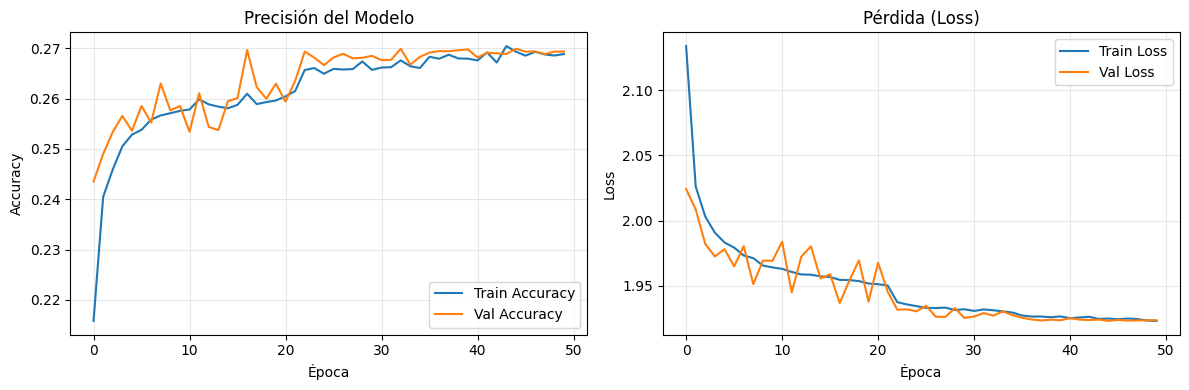


EVALUACIÓN EN TEST

Loss:     1.9231
Accuracy: 0.2699  (26.99%)

REPORTE POR CLASE
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      2766
           1      0.266     0.285     0.275      4100
           2      0.141     0.129     0.135      2661
           3      0.561     0.646     0.601      4514
           4      0.206     0.448     0.282      4177
           5      0.175     0.210     0.191      2015
           6      0.145     0.178     0.160      2112
           7      0.146     0.015     0.028      2167
           8      0.135     0.041     0.063      2045
           9      0.282     0.514     0.364      1470
          10      0.180     0.019     0.035      1510
          11      0.523     0.197     0.286       463

    accuracy                          0.270     30000
   macro avg      0.230     0.224     0.202     30000
weighted avg      0.235     0.270     0.234     30000



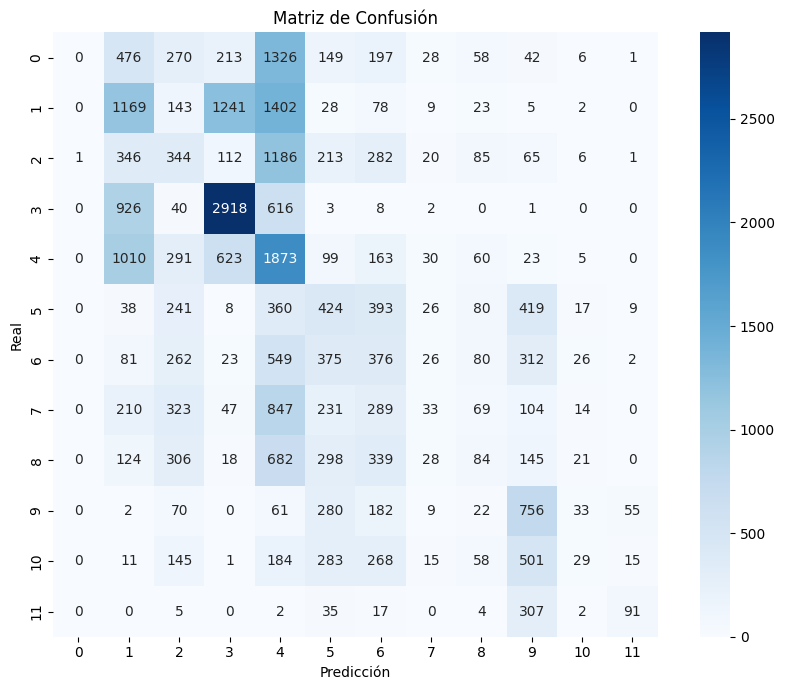

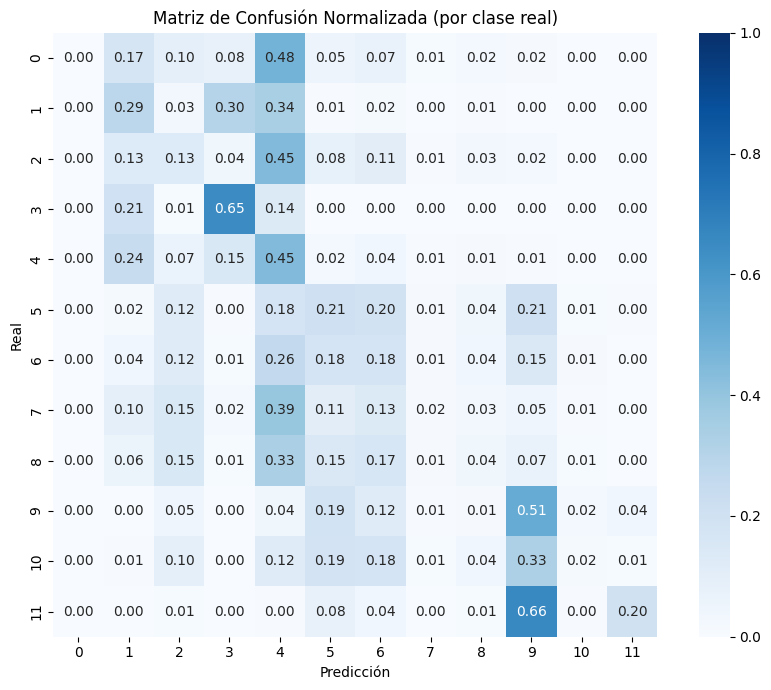


CONFIANZA DEL MODELO
Confianza media cuando acierta: 0.366
Confianza media cuando falla:   0.234


In [6]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    #Capa 1:
    layers.Dense(512, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    
    #Capa 2:                            # Regularización contra overfitting
    layers.Dense(256, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.2),
    
    #Capa 3:
    layers.Dense(128, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.3),
    
    #Capa de salida
    layers.Dense(num_clases, activation='softmax')    # Softmax para multiclase
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Checpoints para guardar el mejor resultado
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "mejor_resultado.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    ),
    checkpoint_cb
]

# Calcular pesos basados en y_train
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

print("Iniciando entrenamiento...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# Curbas de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EVALUACIÓN EN TEST")
print("="*60)

loss, accuracy = model.evaluate(test_ds, verbose=0)
print(f"\nLoss:     {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

# Predicciones
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Métricas por clase
print("\n" + "="*60)
print("REPORTE POR CLASE")
print("="*60)
print(classification_report(y_true, y_pred, digits=3))

# Matroz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    square=True
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    cbar=True,
    square=True,
    vmin=0,
    vmax=1
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión Normalizada (por clase real)')
plt.tight_layout()
plt.show()

confianzas = np.max(y_pred_probs, axis=1)
aciertos = (y_pred == y_true)

print("\n" + "="*60)
print("CONFIANZA DEL MODELO")
print("="*60)
print(f"Confianza media cuando acierta: {confianzas[aciertos].mean():.3f}")
print(f"Confianza media cuando falla:   {confianzas[~aciertos].mean():.3f}")